In [1]:
!pip install pandas seaborn matplotlib tqdm

In [2]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as img
import matplotlib.patches as patches
from tqdm import tqdm

from glob import glob
import os

import platform

In [3]:
# 윈도우 한글 폰트 설정 코드

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")

현재 설정된 폰트: ['Malgun Gothic']


In [4]:
# 윈도우 실제 경로(다운 받은 파일 경로)를 그대로 복사하되, 앞에 r을 꼭 붙여주세요.
actual_path = r'C:\Users\chocy\Downloads\ai-07-object-detection\sprint_ai_project1_data\train_annotations'


# recursive = True를 쓰면 하위 폴더를 모두 뒤져서 찾습니다.

json_files = glob(os.path.join(actual_path, '**', '*.json'), recursive=True)

print(f'찾은 총 json 파일 개수 : {len(json_files)}')

# 파일이 있는 경우, 첫 번째 파일의 경로를 출력해서 잘 찾았는지 확인
if json_files:
    print(f'첫 번째 파일 샘플 경로 : {json_files[0]}')

    # 구조 확인용
    with open(json_files[0], 'r', encoding='utf-8') as f:
        sample = json.load(f)
    print("\n--- JSON 데이터 구조(Key) ---")
    print(sample.keys())

찾은 총 json 파일 개수 : 763
첫 번째 파일 샘플 경로 : C:\Users\chocy\Downloads\ai-07-object-detection\sprint_ai_project1_data\train_annotations\K-001900-016548-019607-029451_json\K-001900\K-001900-016548-019607-029451_0_2_0_2_70_000_200.json

--- JSON 데이터 구조(Key) ---
dict_keys(['images', 'type', 'annotations', 'categories'])


['images', 'type', 'annotations', 'categories'] 와 같은 데이터셋 구조로 보아, 위 데이터는 전형적인 COCO(Common Objects in Context)데이터셋의 변형임을 확인하였다.

In [5]:
# 모든 행, 열 표시
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)



In [6]:
all_rows = []

for file_path in tqdm(json_files, desc='상세 메타데이터 수집 중'):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

        # 이미지 메타데이터(40개 클래스)
        img_metadata = data['images'][0]

        # 카테고리 이름 매핑
        cat_map = {cat['id']: cat['name'] for cat in data['categories']}

        # 어노테이션(BBox 등) 반복
        for anno in data['annotations']:
            # 어노테이션 정보 + 이미지 메타데이터 합치기
            combined_info = {**img_metadata, **anno} #dict 합치기

            # 카테고리 이름 추가
            combined_info['category_name'] = cat_map.get(anno['category_id'], 'unknown')
            combined_info['source_file'] = file_path

            all_rows.append(combined_info)

# 전체 통합 데이터프레임 생성
df_total = pd.DataFrame(all_rows)

print(f'통합 데이터프레임 형태: {df_total.shape}') # (행, 열) 확인
df_total.head()

상세 메타데이터 수집 중: 100%|██████████| 763/763 [00:00<00:00, 3969.88it/s]


통합 데이터프레임 형태: (763, 59)


,file_name,width,height,imgfile,drug_N,drug_S,back_color,drug_dir,light_color,camera_la,camera_lo,size,dl_idx,dl_mapping_code,dl_name,dl_name_en,img_key,dl_material,dl_material_en,dl_custom_shape,dl_company,dl_company_en,di_company_mf,di_company_mf_en,item_seq,di_item_permit_date,di_class_no,di_etc_otc_code,di_edi_code,chart,drug_shape,thick,leng_long,leng_short,print_front,print_back,color_class1,color_class2,line_front,line_back,img_regist_ts,form_code_name,mark_code_front_anal,mark_code_back_anal,mark_code_front_img,mark_code_back_img,mark_code_front,mark_code_back,change_date,id,area,iscrowd,bbox,category_id,ignore,segmentation,image_id,category_name,source_file
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,70,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,133,35910,0,"[644, 845, 189, 190]",1900,0,[],34,보령부스파정 5mg,C:\Users\chocy\Downloads\ai-07-object-detectio...
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,75,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,134,32761,0,"[148, 241, 181, 181]",1900,0,[],35,보령부스파정 5mg,C:\Users\chocy\Downloads\ai-07-object-detectio...
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,90,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,135,33488,0,"[167, 248, 184, 182]",1900,0,[],36,보령부스파정 5mg,C:\Users\chocy\Downloads\ai-07-object-detectio...
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,70,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,NaN,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136,57121,0,"[144, 799, 239, 239]",16548,0,[],34,가바토파정 100mg,C:\Users\chocy\Downloads\ai-07-object-detectio...
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,75,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,NaN,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137,52658,0,"[578, 222, 233, 226]",16548,0,[],35,가바토파정 100mg,C:\Users\chocy\Downloads\ai-07-object-detectio...


In [7]:
df_total['bbox_tuple'] = df_total['bbox'].apply(tuple)

dup = df_total[df_total.duplicated(
    subset=['file_name', 'bbox_tuple'],
    keep=False
)]

len(dup)

6

In [8]:
# 어떤 데이터가 중복인지 상세 확인
print("--- [중복 데이터 상세 목록] ---")
display(dup.sort_values(by=['file_name', 'bbox_tuple']))

--- [중복 데이터 상세 목록] ---


,file_name,width,height,imgfile,drug_N,drug_S,back_color,drug_dir,light_color,camera_la,camera_lo,size,dl_idx,dl_mapping_code,dl_name,dl_name_en,img_key,dl_material,dl_material_en,dl_custom_shape,dl_company,dl_company_en,di_company_mf,di_company_mf_en,item_seq,di_item_permit_date,di_class_no,di_etc_otc_code,di_edi_code,chart,drug_shape,thick,leng_long,leng_short,print_front,print_back,color_class1,color_class2,line_front,line_back,img_regist_ts,form_code_name,mark_code_front_anal,mark_code_back_anal,mark_code_front_img,mark_code_back_img,mark_code_front,mark_code_back,change_date,id,area,iscrowd,bbox,category_id,ignore,segmentation,image_id,category_name,source_file,bbox_tuple
15,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,70,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,NaN,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4683,76494,0,"[88, 255, 366, 209]",16548,0,[],1228,가바토파정 100mg,C:\Users\chocy\Downloads\ai-07-object-detectio...,"(88, 255, 366, 209)"
21,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,K-033009,정상알약,연회색 배경,앞면,주백색,70,0,200,33009,K-033009,신바로정,Shinbaro Tab.,http://connectdi.com/design/img/drug/148431162...,자오가·우슬·방풍·두충·구척·흑두건조엑스,Acanthopanax·Achyranthes·Ledebouriella etc Dri...,"정제, 저작정",(주)녹십자,Green Cross Corp,,,201401963,20140423,[01140]해열.진통.소염제,전문의약품,643605030,갈색의 장방형 필름코팅정,타원형,5.30,14.50,8.00,S300,,갈색,,,,20140925,필름코팅정,,,,,,,20151015,4691,76494,0,"[88, 255, 366, 209]",33009,0,[],1228,신바로정,C:\Users\chocy\Downloads\ai-07-object-detectio...,"(88, 255, 366, 209)"
420,K-003351-020238-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-020238-031863_0_2_0_2_70_000_200.png,K-003351,정상알약,연회색 배경,앞면,주백색,70,0,200,3351,K-003351,일양하이트린정 2mg,Hytrin Tab. 2mg Ilyang,http://connectdi.com/design/img/drug/147765842...,테라조신염산염수화물,Terazosin Hydrochloride Hydrate,"정제, 저작정",일양약품(주),Ilyang Pharmaceutical,,,199101125,19910626,[02590]기타의 비뇨생식기관 및 항문용약,전문의약품,"641702010,A09503981",오랜지색 또는 노란색의 원형정제.,원형,2.76,7.01,7.01,I분할선Y,HT,주황,,-,,20041222,나정,,,,,,,20170328,3444,36290,0,"[446, 844, 190, 191]",3351,0,[],907,일양하이트린정 2mg,C:\Users\chocy\Downloads\ai-07-object-detectio...,"(446, 844, 190, 191)"
422,K-003351-020238-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-020238-031863_0_2_0_2_70_000_200.png,K-020238,정상알약,연회색 배경,앞면,주백색,70,0,200,20238,K-020238,플라빅스정 75mg,Plavix Tab. 75mg,http://connectdi.com/design/img/drug/149883724...,클로피도그렐황산염,Clopidogrel Bisulfate,"정제, 저작정",(주)한독,Handok,Sanofi Winthrop Industrie,,200700907,20070122,[02180]동맥경화용제,전문의약품,"652101570,A07404851",분홍색의 원형필름코팅정,원형,4.00,8.50,8.50,75,1171,분홍,,,,20041222,필름코팅정,,,,,,,20210426,3441,36290,0,"[446, 844, 190, 191]",20238,0,[],907,플라빅스정 75mg,C:\Users\chocy\Downloads\ai-07-object-detectio...,"(446, 844, 190, 191)"
485,K-003351-029667-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-029667-031863_0_2_0_2_70_000_200.png,K-003351,정상알약,연회색 배경,앞면,주백색,70,0,200,3351,K-003351,일양하이트린정 2mg,Hytrin Tab. 2mg Ilyang,http://connectdi.com/design/img/drug/147765842...,테라조신염산염수화물,Terazosin Hydrochloride Hydrate,"정제, 저작정",일양약품(주),Ilyang Pharmaceutical,,,199101125,19910626,[02590]기타의 비뇨생식기관 및 항문용약,전문의약품,"641702010,A09503981",오랜지색 또는 노란색의 원형정제.,원형,2.76,7.01,7.01,I분할선Y,HT,주황,,-,,20041222,나정,,,,,,,20170328,791,41615,0,"[178, 249, 205, 203]",3351,0,[],208,일양하이트린정 2mg,C:\Users\chocy\Downloads\ai-07-object-detectio...,"(178, 249, 205, 203)"
489,K-003351-029667-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-029667-031863_0_2_0_2_70_000_200.png,K-031863,정상알약,연회색 배경,앞면,주백색,70,0,200,31863,K-031863,아질렉트정(라사길린메실산염),Azilect Tab.,http://connectdi.com/design/img/drug/147426780...,라사길린메실산염,Rasagiline Mesylate,"정제, 저작정",한국룬드벡(주),Lundbeck Korea,Teva Pharmaceutical Industries Ltd.,,201309347,20130913,[01190]기타의 중추신경용약,전문의약

하나의 바운딩 박스(BBox) 안에 서로 다른 두 개의 알약 정보가 라벨링되어있는 것을 확인.

예시
- 파일명: ..._0_2_0_2_70_000_200.png (동일)
- BBox: [446, 844, 190, 191] (동일)
- 라벨 1 (420): 하이트린정 (주황색, 원형)
- 라벨 2 (422): 플라빅스정 (분홍색, 원형)

한 장의 사진 속 동일한 위치에 두 종류의 알약이 겹쳐서 존재할 수는 없으므로 물리적으로 불가능하다고 판단.
이에 따라 이 데이터를 drop 하였음.

In [9]:
# 파일명과 BBox가 같은 데이터들을 모두 식별 (모든 중복군 추출)
duplicates_all = df_total[df_total.duplicated(subset=['file_name', 'bbox_tuple'], keep=False)]

# 이 중복된 데이터들의 인덱스를 전체 데이터에서 삭제
df_total_cleaned = df_total.drop(duplicates_all.index).copy()

print(f"오류 데이터 {len(duplicates_all)}건을 완전히 제거했습니다.")
print(f"남은 정상 데이터 개수: {len(df_total_cleaned)}")

오류 데이터 6건을 완전히 제거했습니다.
남은 정상 데이터 개수: 757


In [10]:
df_valid = df_total[['drug_N', 'drug_S', 'dl_idx', 'dl_mapping_code', 'img_key', 
    'dl_material', 'dl_material_en', 'dl_custom_shape', 'dl_company', 
    'dl_company_en', 'di_company_mf', 'di_company_mf_en', 'item_seq', 
    'di_item_permit_date', 'di_class_no', 'di_etc_otc_code', 'di_edi_code', 
    'chart', 'drug_shape', 'thick', 'leng_long', 'leng_short', 
    'print_front', 'print_back', 'color_class1', 'color_class2', 
    'line_front', 'line_back', 'img_regist_ts', 'form_code_name', 
    'mark_code_front_anal', 'mark_code_back_anal', 'mark_code_front_img', 
    'mark_code_back_img', 'mark_code_front', 'mark_code_back', 'change_date']]
df_valid.head()

,drug_N,drug_S,dl_idx,dl_mapping_code,img_key,dl_material,dl_material_en,dl_custom_shape,dl_company,dl_company_en,di_company_mf,di_company_mf_en,item_seq,di_item_permit_date,di_class_no,di_etc_otc_code,di_edi_code,chart,drug_shape,thick,leng_long,leng_short,print_front,print_back,color_class1,color_class2,line_front,line_back,img_regist_ts,form_code_name,mark_code_front_anal,mark_code_back_anal,mark_code_front_img,mark_code_back_img,mark_code_front,mark_code_back,change_date
0,K-001900,정상알약,1900,K-001900,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825
1,K-001900,정상알약,1900,K-001900,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825
2,K-001900,정상알약,1900,K-001900,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825
3,K-016548,정상알약,16548,K-016548,NaN,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,K-016548,정상알약,16548,K-016548,NaN,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_valid.info(max_cols=1000)

<class 'pandas.DataFrame'>
RangeIndex: 763 entries, 0 to 762
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   drug_N                763 non-null    str    
 1   drug_S                763 non-null    str    
 2   dl_idx                763 non-null    str    
 3   dl_mapping_code       763 non-null    str    
 4   img_key               745 non-null    str    
 5   dl_material           763 non-null    str    
 6   dl_material_en        763 non-null    str    
 7   dl_custom_shape       763 non-null    str    
 8   dl_company            763 non-null    str    
 9   dl_company_en         763 non-null    str    
 10  di_company_mf         763 non-null    str    
 11  di_company_mf_en      763 non-null    str    
 12  item_seq              763 non-null    int64  
 13  di_item_permit_date   763 non-null    str    
 14  di_class_no           763 non-null    str    
 15  di_etc_otc_code       763 non-null

In [12]:
# info에서 색상데이터 총 18개 결측치를 확인하였으므로 출력
print('색상 별 결측치 개수:')
print(df_valid[['color_class1', 'color_class2']].isnull().sum())

# 색상 2가 없는 경우에는 분석 상 편의를 위해 'None'으로 처리
df_valid['color_class2'] = df_valid['color_class2'].fillna('None')

색상 별 결측치 개수:
color_class1    18
color_class2    18
dtype: int64


In [13]:
df_valid['color_class1'].value_counts()

color_class1
하양        211
주황        190
분홍        119
노랑         98
갈색         56
초록         54
노랑, 투명      8
연두          6
파랑          3
Name: count, dtype: int64

In [14]:
df_valid['color_class2'].value_counts()

color_class2
        693
하양       31
None     18
파랑       12
초록        9
Name: count, dtype: int64

In [15]:
# 공백 데이터 > None 으로 처리
df_valid['color_class2'] = df_valid['color_class2'].str.strip().replace('', 'None')

# 다시 확인
df_valid['color_class2'].value_counts()

color_class2
None    711
하양       31
파랑       12
초록        9
Name: count, dtype: int64

특이사항
1. 색상 1의 '노랑, 투명' : '노랑'으로 합칠지, 별도의 클래스로 두어야 할 지 확인 필요.
2. 색상 2 중복 여부 : 색상 1이 '하양'인데, 색상 2 역시 '하양'인 경우, 확인 필요.

In [16]:
# 단색/복합색 여부를 판단
def get_color_type(row):
    c1 = row['color_class1']
    c2 = row['color_class2']
    if c2 == 'None' or c1 == c2:
        return c1 # 단색
    else:
        return f'{c1}+{c2}'  # 복합색

df_valid['color_final'] = df_valid.apply(get_color_type, axis=1)

df_valid['color_final'].value_counts()

color_final
하양        199
주황        190
분홍        119
노랑         82
갈색         56
초록         54
노랑+하양      16
하양+파랑      12
노랑, 투명      8
연두          6
파랑          3
Name: count, dtype: int64

In [17]:
# '노랑, 투명' 을 포함하는 데이터의 인덱스 추출
target_indices = df_total[df_total['color_class1'].str.contains('노랑, 투명', na=False)].index

print(f'확인해야 할 데이터 개수: {len(target_indices)}')
print(f'해당 인덱스: {target_indices.tolist()}')

# 해당 데이터들의 주요 정보 확인
df_check = df_total.loc[target_indices, ['drug_N', 'color_class1', 'color_class2', 'file_name']]
df_check

확인해야 할 데이터 개수: 8
해당 인덱스: [113, 273, 274, 278, 281, 284, 287, 290]


,drug_N,color_class1,color_class2,file_name
113,K-016688,"노랑, 투명",,K-003351-003832-016688_0_2_0_2_70_000_200.png
273,K-016688,"노랑, 투명",,K-003351-016688-018147_0_2_0_2_70_000_200.png
274,K-016688,"노랑, 투명",,K-003351-016688-018147_0_2_0_2_75_000_200.png
278,K-016688,"노랑, 투명",,K-003351-016688-018357_0_2_0_2_75_000_200.png
281,K-016688,"노랑, 투명",,K-003351-016688-019232_0_2_0_2_90_000_200.png
284,K-016688,"노랑, 투명",,K-003351-016688-020014_0_2_0_2_90_000_200.png
287,K-016688,"노랑, 투명",,K-003351-016688-031863_0_2_0_2_90_000_200.png
290,K-016688,"노랑, 투명",,K-003351-016688-041768_0_2_0_2_90_000_200.png


In [18]:
def view_image(index):
    # 확인하고 싶은 인덱스 선택
    idx_to_view = target_indices[index]

    # 이미지 파일 이름 추출
    file_name = df_total.loc[idx_to_view, 'file_name']

    # 경로 조합
    image_path = os.path.join('train_images', file_name)

    # 이미지 출력
    if os.path.exists(image_path):
        plt.figure(figsize=(8, 8))
        image = img.imread(image_path)
        plt.imshow(image)
        plt.title(f"Index: {idx_to_view} | Color: {df_total.loc[idx_to_view, 'color_class1']}")
        plt.axis('off')
        plt.show()
    else:
        print(f'이미지를 찾을 수 없습니다.: {image_path}')

In [19]:
def view_images_grid(indices, cols=4):
    rows = (len(indices) + cols -1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        row_data = df_total.loc[idx]
        file_name = row_data['file_name']
        image_path = os.path.join('train_images', file_name)

        if os.path.exists(image_path):
            image = img.imread(image_path)
            axes[i].imshow(image)

            # BBox 그리기
            bx, by, bw, bh = row_data['bbox']
            rect = patches.Rectangle((bx, by), bw, bh, linewidth=2, edgecolor='r', facecolor='none')
            axes[i].add_patch(rect)

            axes[i].set_title(f'Idx: {idx}\n{row_data['color_class1']}')
        else:
            axes[i].text(0.5, 0.5, 'Not Found', ha='center')
        axes[i].axis('off')

    # 빈 서브플롯 숨기기
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

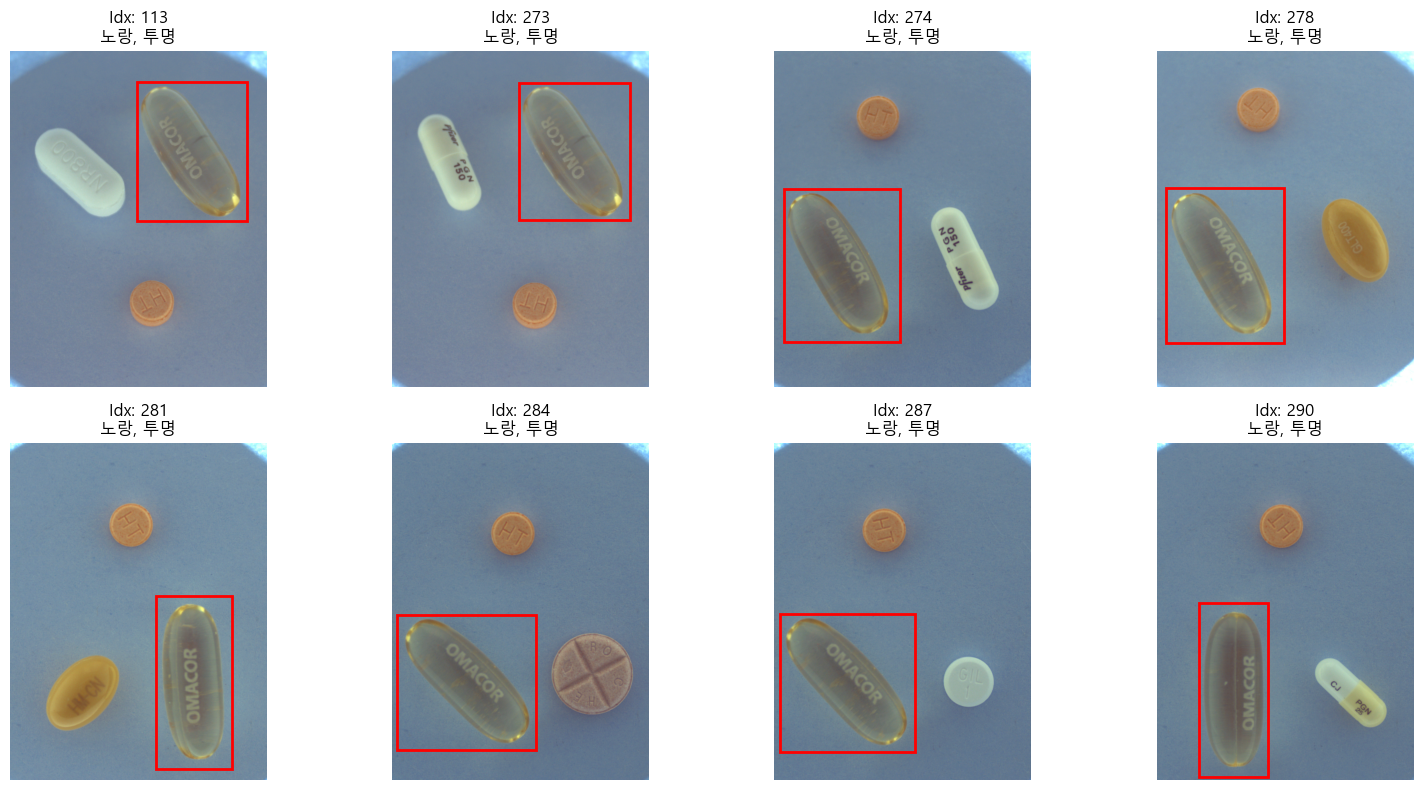

In [20]:
view_images_grid(target_indices)

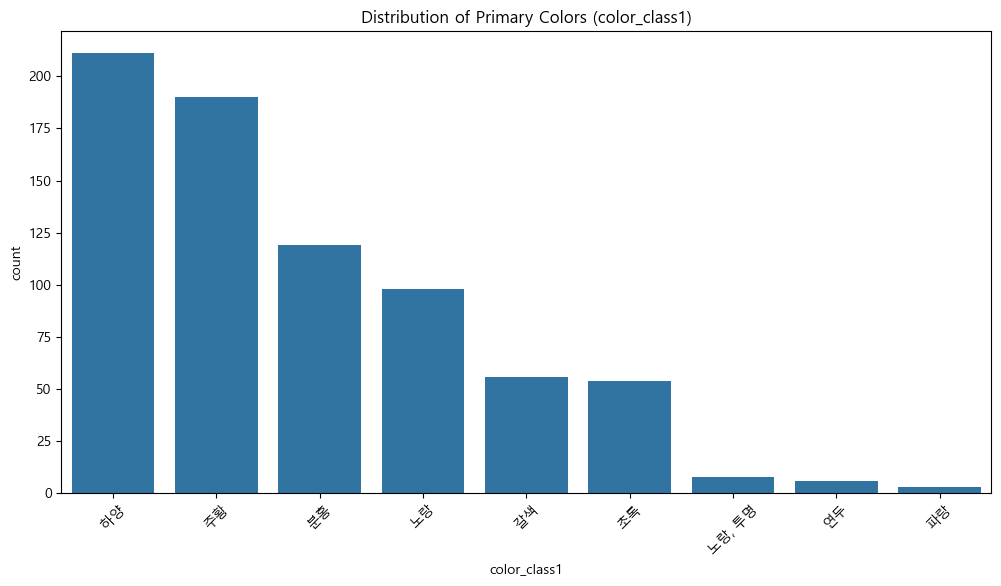

In [21]:
# 색상 1 분포 시각화
plt.figure(figsize=(12, 6))
sns.countplot(data=df_valid, x='color_class1', order=df_valid['color_class1'].value_counts().index)
plt.title('Distribution of Primary Colors (color_class1)')
plt.xticks(rotation=45)
plt.show()

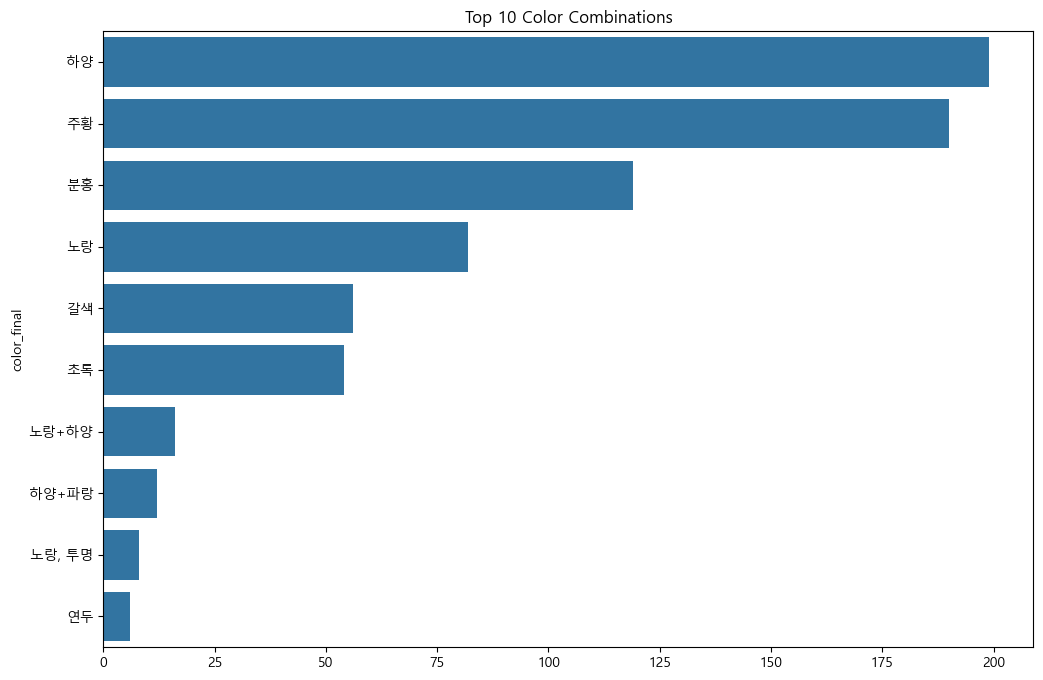

In [22]:
# 상위 10개 조합 확인

plt.figure(figsize=(12, 8))
top_10_pairs = df_valid['color_final'].value_counts().head(10)
sns.barplot(x=top_10_pairs.values, y=top_10_pairs.index)
plt.title('Top 10 Color Combinations')
plt.show()

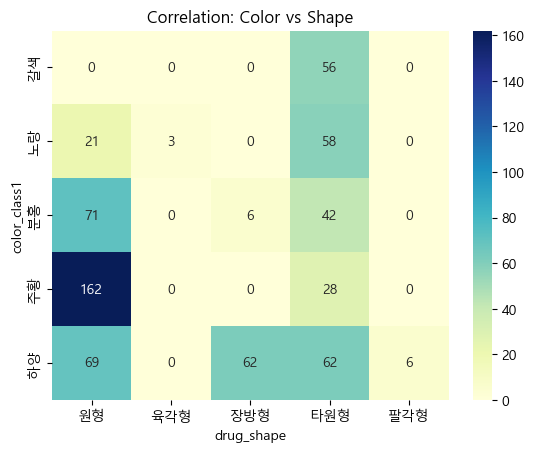

In [23]:
# 상위 5개 색상과 상위 5개 모양으로 교차 테이블 생성
top_colors = df_valid['color_final'].value_counts().nlargest(5).index
top_shapes = df_valid['drug_shape'].value_counts().nlargest(5).index

df_subset = df_valid[df_valid['color_final'].isin(top_colors) & df_valid['drug_shape'].isin(top_shapes)]

# 히트맵 시각화
color_shape_ct = pd.crosstab(df_subset['color_class1'], df_subset['drug_shape'])
sns.heatmap(color_shape_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Correlation: Color vs Shape')
plt.show()

### 분할선 및 마크 분석

In [24]:
# 분석에 필요한 컬럼들만 추출
line_mark_cols = [
    'line_front', 'line_back', 
    'mark_code_front_anal', 'mark_code_back_anal',
    'mark_code_front_img', 'mark_code_back_img',
    'drug_N', 'file_name' # 추적을 위한 기본 정보
]

df_line_mark = df_total[line_mark_cols].copy()

# 데이터 타입 